In [1]:
import matplotlib.pylab as plt 
%matplotlib inline
import numpy as np
import rubin_sim.splat as maf
import pandas as pd
import sqlite3
import healpy as hp
import copy
import datetime

from os.path import basename

In [2]:
db_file = "templates_decdep_lateroll_v5.2.0_10yrs.db"
run_name = basename(db_file).replace('.db', '')
con = sqlite3.connect(db_file)
df = pd.read_sql('select * from observations;', con)
con.close()
# Convert to a numpy array
visits_array = df.to_records(index=False)



In [3]:


times = np.arange(3653)
metric = maf.AccumulateCountMetric(times)
info = {"run_name": run_name}
sub_data = visits_array
sl = maf.Slicer()
# Run the metics through the slicer
hp_array, info = sl(sub_data, metric, info=info)
#pm = maf.PlotMoll(info=info)
#fig = pm(hp_array, max=np.percentile(hp_array[np.isfinite(hp_array)], 90))
#stats.append(maf.gen_summary_row(info, "median", np.nanmedian(hp_array)))


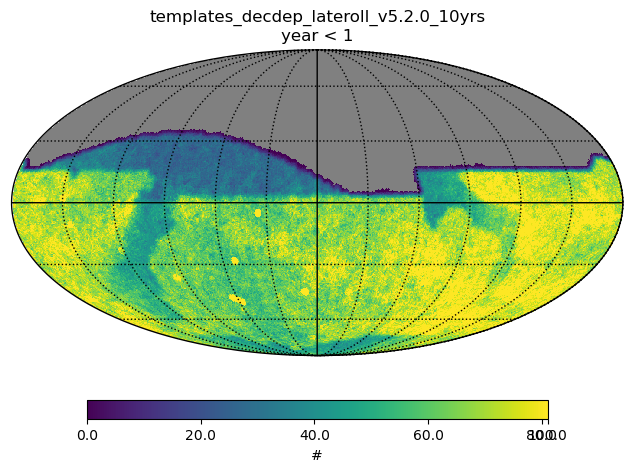

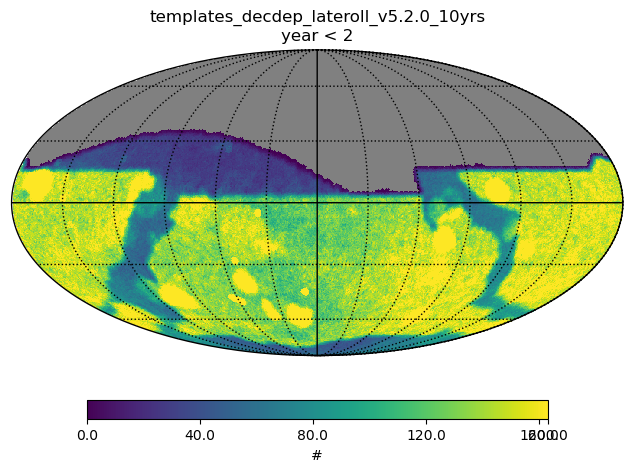

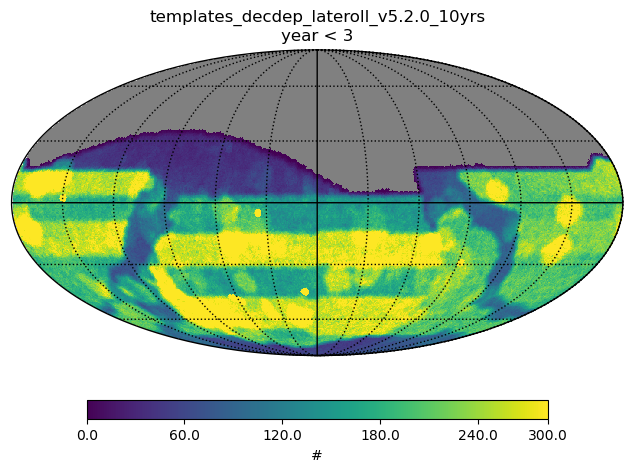

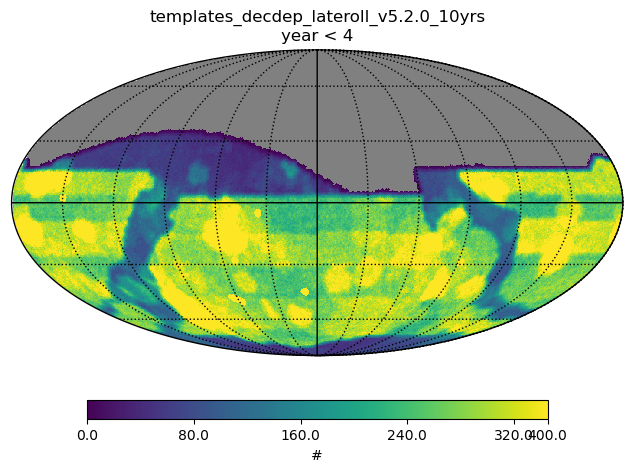

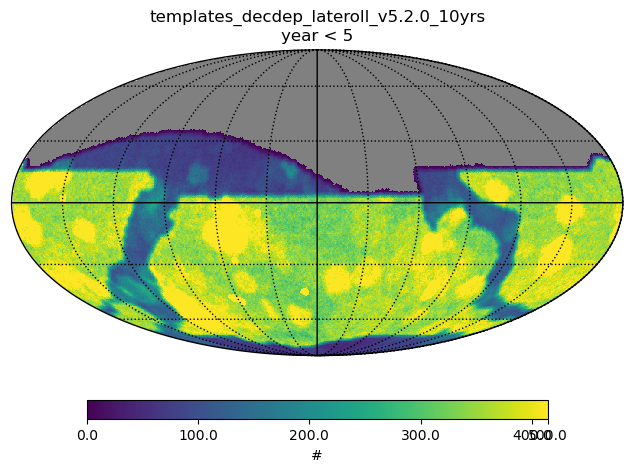

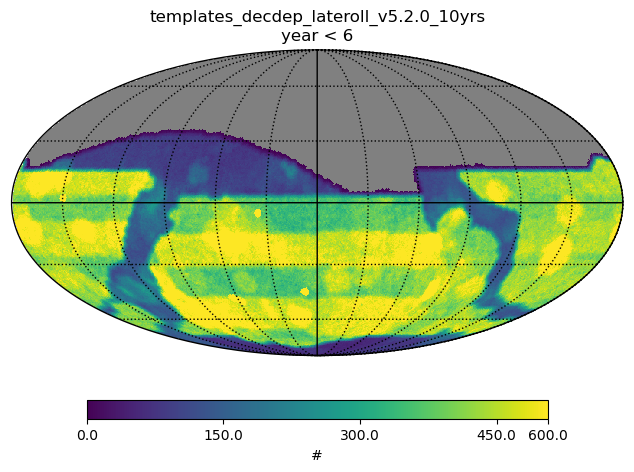

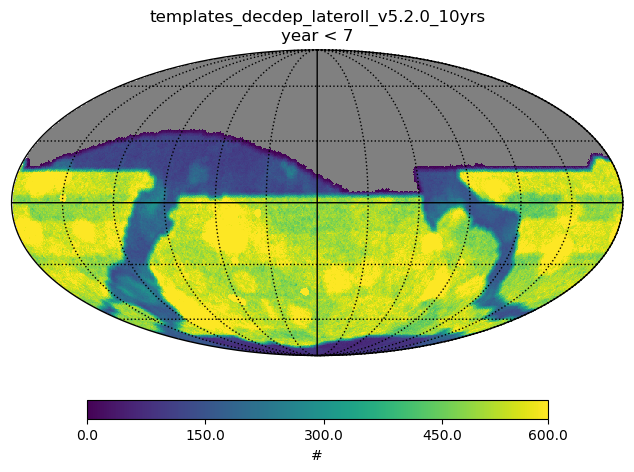

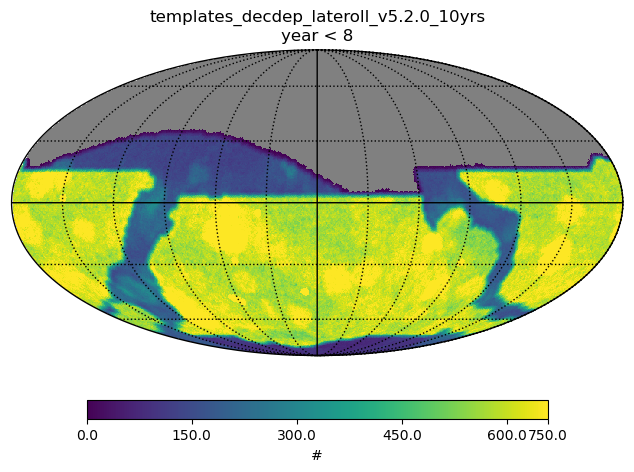

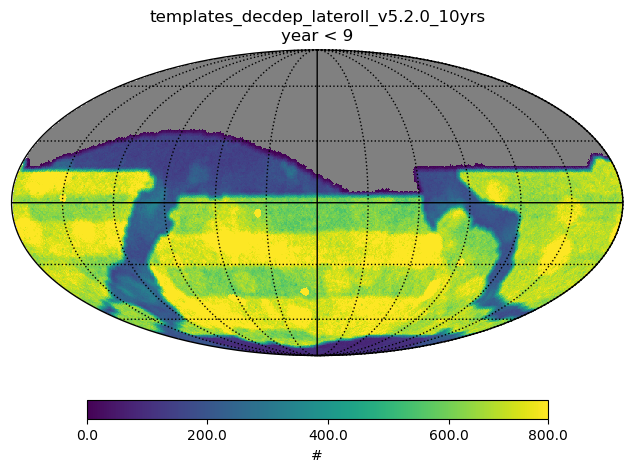

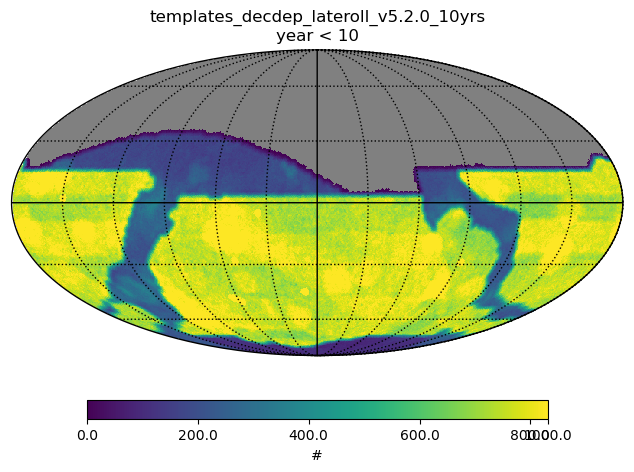

In [6]:
for night in np.arange(1,11)*365:
    arr = hp_array[:,night]
    info['observations_subset'] = "year = %i" % (night/365)
    pm = maf.PlotMoll(info=info)
    fig = pm(arr, max=np.percentile(arr[np.isfinite(arr)], 90))